# In this notebook
I show a quick demo on how to look at the Sentinel-2 data and use it in a data processing pipeline.

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import rasterio as rio

In [2]:
tile_path = '../retiled/'
days = sorted(os.listdir(tile_path))

As you can see, I have 4 days worth of data here.

In total, for 1 year, we will have roughly 150 days with satellite images in them. However, many of these images will be either cloudy or incomplete. So, I'm going to show you what a lot of this data looks like through showing a couple of examples.

In [3]:
# Let's look at the first day's data
first_day = days[0]
tiles = os.listdir(os.path.join(tile_path, first_day))
example_tile_fp = os.path.join(tile_path, first_day, tiles[0])
num_tiles = len(tiles)
print(f"Number of tiles for {first_day}: {num_tiles}")
with rio.open(example_tile_fp) as src:
    data = src.read()

# Does this have data in it?
if (data == 0).all() == False:
    print("Data is present!")
else:
    print("There is no data in this tile.")

Number of tiles for S2_daily_2024-01-03_masked: 256
Data is present!


Great, this tile has some data in it! Let's visualize that. We can do this by treating it as an RGB image. Also, note that we have 256 tiles on this day. If we have roughly 50 good days, then that means we have almost 13,000 images total. Hopefully that's enough!

The Sentinel-2 imagery we downloaded has the following bands:
 - B2: Blue (scale 1/10000)
 - B3: Green (scale 1/10000)
 - B4: Red (scale 1/10000)
 - AOT: Aerosol optical thickness (or depth) (scale 1/1000)
 - WVP: Water Vapor Pressure (scale 1/1000)

Note the scaling -- the data as saved is as an unsigned integer. This might be fine, depending on your purpose, but most likely, you'll want to rescale the data to be a float. Do this by multiplying by the scale. **RGB have the same scale, but AOT and WVP have a different scale!**

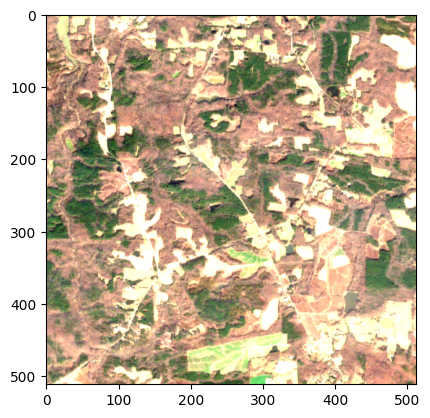

In [ ]:
data = data.astype(np.float32)
# data[data == 0 ] = np.nan
red = data[2, :, :] * 0.0001
blue = data[0, :, :] * 0.0001
green = data[1, :, :] * 0.0001

# concatenate the data and display the image
rgb = np.dstack((red, green, blue))**(1/2.2)
# Clip at 0.3
clip_val = 0.3
rgb[rgb > clip_val] = clip_val
rgb = (rgb - np.nanmin(rgb, axis=(0, 1))) / (np.nanmax(rgb, axis=(0, 1)) - np.nanmin(rgb, axis=(0, 1)))
plt.imshow(rgb)

This is not a particularly informative image. Let's see if we can find another one.

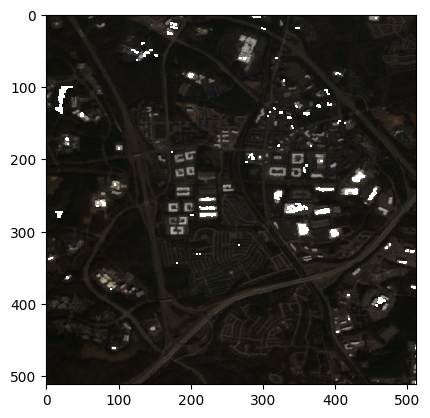

In [6]:
i = 120

example_tile_fp = os.path.join(tile_path, first_day, tiles[i])
num_tiles = len(tiles)
# print(f"Number of tiles for {first_day}: {num_tiles}")
with rio.open(example_tile_fp) as src:
    data = src.read()

scale = 1/10000
red = data[2, :, :] * scale
blue = data[0, :, :] * scale
green = data[1, :, :] * scale

# concatenate the data and display the image
rgb = np.dstack((red, green, blue))
# Clip at 0.3
# rgb[rgb > 0.3] = 0.3
rgb[rgb == 0] = np.nan
plt.imshow(rgb)
plt.show()

This is potentially a bit more informative!

Now, if you look at my code...you'll see a line `rgb[rgb==0] = np.nan`. This is to filter out masked images. The masked approach is not perfect, but I used a fairly standard technique in Google Earth Engine. You'll note in this case, it masks out building roofs (which tend to be white enough for the algorithm to think they are clouds). Building roofs are not always masked out.

Let's show one final example of what the clouded out data looks like -- this makes the point that in general, we likely do want to remove clouds from our images.

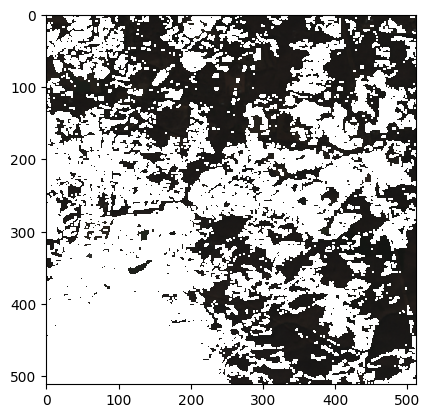

In [23]:
i = 80

example_tile_fp = os.path.join(tile_path, first_day, tiles[i])
num_tiles = len(tiles)
# print(f"Number of tiles for {first_day}: {num_tiles}")
with rio.open(example_tile_fp) as src:
    data = src.read()

scale = 1/10000
red = data[2, :, :] * scale
blue = data[0, :, :] * scale
green = data[1, :, :] * scale

# concatenate the data and display the image
rgb = np.dstack((red, green, blue))
# Clip at 0.3
# rgb[rgb > 0.3] = 0.3
rgb[rgb == 0] = np.nan
plt.imshow(rgb)
plt.show()

This is a very cloudy image. As you can see, it will be hard to extract any meaningful information from this image.